# 데이터 생성

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import folium

In [5]:
# 날짜 생성
dates = pd.date_range('2024-01-01', '2024-12-31')

# 지역과 제품 카테고리 정의
regions = ['서울','부산','대구','광주','인천']
products = ['A','B','C','D']

# 가상의 매출 데이터 생성
data = {
  'date' : np.random.choice(dates, 1000),
  'region' : np.random.choice(regions, 1000),
  'product' : np.random.choice(products, 1000),
  'sales' : np.random.randint(100, 1000, 1000),       # 매출 100~1000만원
  'profit' : np.random.randint(10, 200, 1000)         # 이익 10~200만원
}

df = pd.DataFrame(data)
df

,date,region,product,sales,profit
0,2024-08-24,광주,D,672,176
1,2024-12-25,부산,C,437,60
2,2024-12-23,인천,D,850,190
3,2024-08-09,광주,D,379,103
4,2024-02-17,부산,B,859,194
...,...,...,...,...,...
995,2024-03-20,인천,C,323,137
996,2024-09-25,부산,C,299,145
997,2024-10-09,인천,B,525,20
998,2024-06-07,인천,A,528,135


In [13]:
df2 = df.sort_values('date', ascending=True)
df2

,date,region,product,sales,profit
449,2024-01-01,인천,D,489,61
456,2024-01-01,부산,D,314,140
564,2024-01-02,대구,C,758,107
233,2024-01-02,부산,B,809,165
671,2024-01-03,서울,D,257,47
...,...,...,...,...,...
597,2024-12-30,인천,B,623,118
118,2024-12-30,대구,C,910,167
437,2024-12-31,서울,A,578,51
170,2024-12-31,서울,B,301,158


In [14]:
df2.to_csv('./data/random_ex_data.csv',
           index=False,
           encoding='utf-8-sig')

In [18]:
data2 = pd.read_csv('./data/random_ex_data.csv')
df3 = pd.DataFrame(data2)
df3

,date,region,product,sales,profit
0,2024-01-01,인천,D,489,61
1,2024-01-01,부산,D,314,140
2,2024-01-02,대구,C,758,107
3,2024-01-02,부산,B,809,165
4,2024-01-03,서울,D,257,47
...,...,...,...,...,...
995,2024-12-30,인천,B,623,118
996,2024-12-30,대구,C,910,167
997,2024-12-31,서울,A,578,51
998,2024-12-31,서울,B,301,158


In [19]:
! pip install plotly folium

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 71.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [folium]2m2/5 [plotly]s]


In [29]:
df3 = pd.read_csv('./data/random_ex_data.csv')
df3['date'] = pd.to_datetime(df3['date'])
df3


,date,region,product,sales,profit
0,2024-01-01,인천,D,489,61
1,2024-01-01,부산,D,314,140
2,2024-01-02,대구,C,758,107
3,2024-01-02,부산,B,809,165
4,2024-01-03,서울,D,257,47
...,...,...,...,...,...
995,2024-12-30,인천,B,623,118
996,2024-12-30,대구,C,910,167
997,2024-12-31,서울,A,578,51
998,2024-12-31,서울,B,301,158


In [30]:
type(df['date'])

pandas.core.series.Series

In [38]:
import matplotlib.pyplot as plt
from matplotlib import font_manager

font_path = '/mnt/c/Windows/Fonts/malgun.ttf'
font_manager.fontManager.addfont(font_path)

font_name = font_manager.FontProperties(
    fname=font_path
).get_name()

plt.rcParams['font.family'] = font_name
plt.rcParams['axes.unicode_minus'] = False

# Seaborn

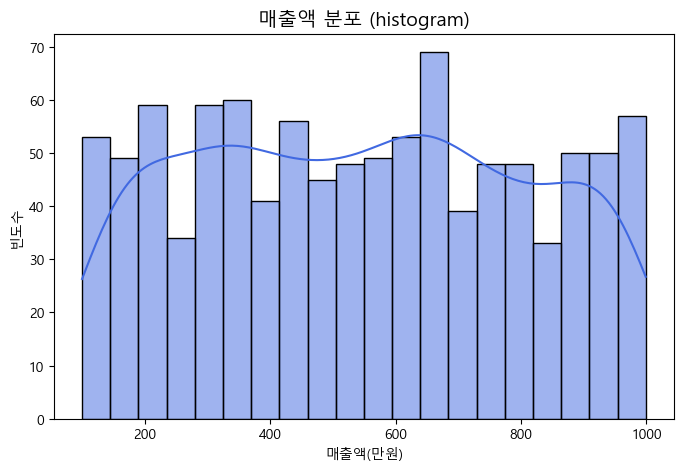

In [39]:
# 매출액(sales) 분포 히스토그램 -> 단일 변수의 분포(빈도)를 시각적으로 파악

plt.figure(figsize=(8,5))
sns.histplot(df['sales'], bins=20, kde=True, color='royalblue')
plt.title('매출액 분포 (histogram)', fontsize=14)
plt.xlabel('매출액(만원)')
plt.ylabel('빈도수')
plt.show()

/tmp/ipykernel_51212/2552461819.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='region', y='sales', data=df, palette='Set2')


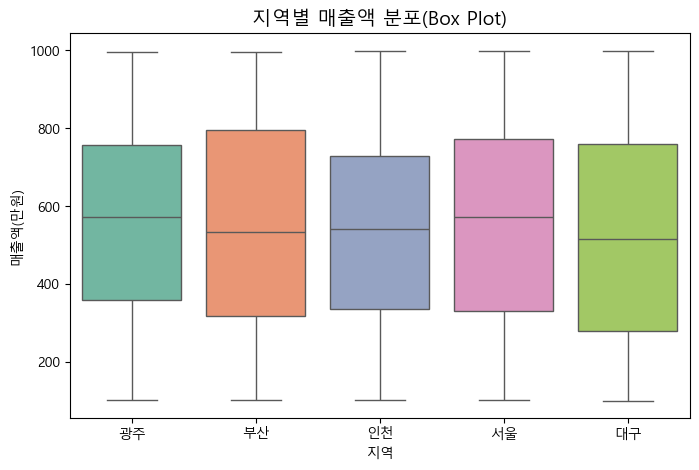

In [40]:
# 지역별 매출액 박스플롯통한 분포 비교

plt.figure(figsize=(8,5))
sns.boxplot(x='region', y='sales', data=df, palette='Set2')

plt.title('지역별 매출액 분포(Box Plot)', fontsize=14)
plt.xlabel('지역')
plt.ylabel('매출액(만원)')
plt.show()

/tmp/ipykernel_51212/2609026980.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


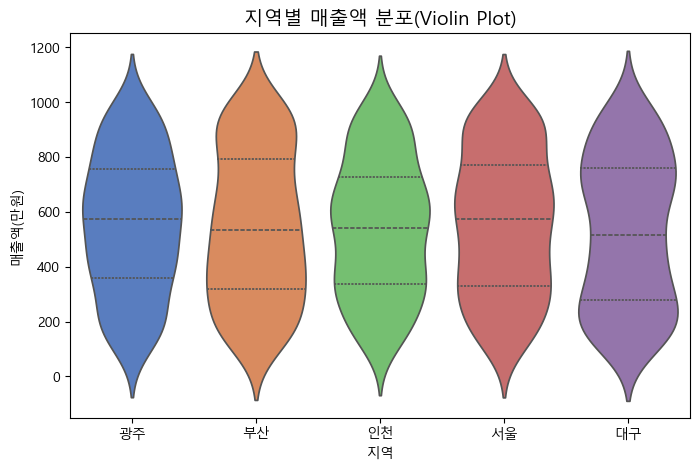

In [41]:
plt.figure(figsize=(8, 5))

sns.violinplot(
    x='region',
    y='sales',
    data=df,
    inner='quartile',
    palette='muted'
)

plt.title('지역별 매출액 분포(Violin Plot)', fontsize=14)
plt.xlabel('지역')
plt.ylabel('매출액(만원)')

plt.show()

/tmp/ipykernel_51212/1017016309.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x='product', y='sales', data=df, estimator=np.mean, ci='sd', palette='coolwarm')
/tmp/ipykernel_51212/1017016309.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='product', y='sales', data=df, estimator=np.mean, ci='sd', palette='coolwarm')


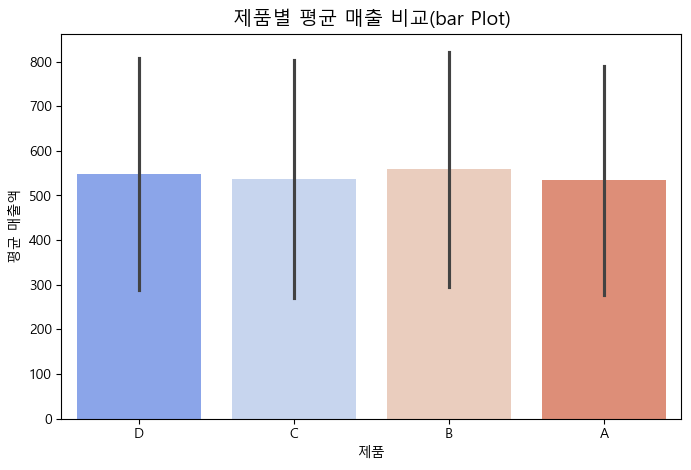

In [43]:
# 제품별 평균 메출 비교 (범주형 데이터의 평균/합계 비교)
plt.figure(figsize=(8,5))
sns.barplot(x='product', y='sales', data=df, estimator=np.mean, ci='sd', palette='coolwarm')

plt.title('제품별 평균 매출 비교(bar Plot)', fontsize=14)
plt.xlabel('제품')
plt.ylabel('평균 매출액')

plt.show()

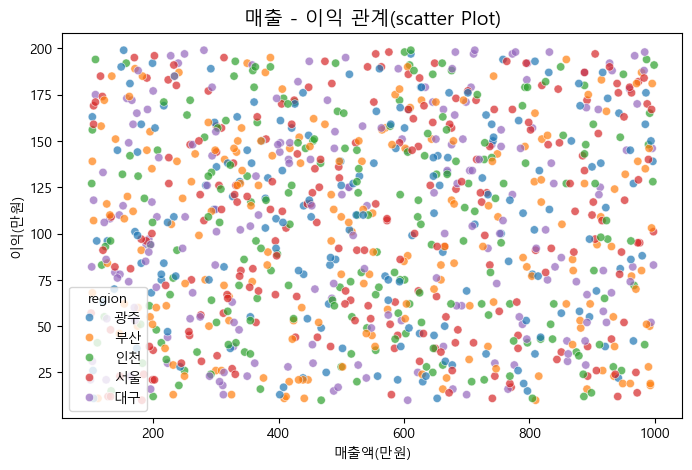

In [44]:
# 매출액(sales) 와 이익(profit) 의 상관관계 -> 두 연속형 변수 간의 상관 관계 시각화
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='sales', y='profit', hue='region', alpha=0.7)  # hue는 지역별 구분을 위해 색깔을 분기치라는 의미

plt.title('매출 - 이익 관계(scatter Plot)', fontsize=14)
plt.xlabel('매출액(만원)')
plt.ylabel('이익(만원)')
plt.show()

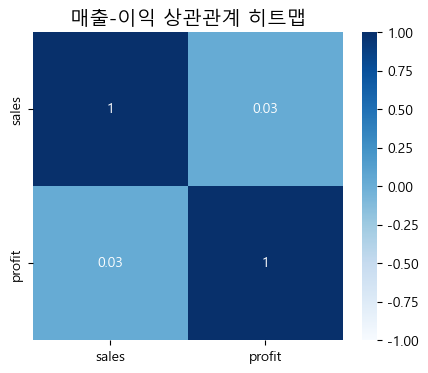

In [45]:
# 매출과 이익의 상관관계 히트맵 --> 여러 변수간의 상관계수를 색상으로 표현하는 목적의 그래프

plt.figure(figsize=(5,4))
corr = df[['sales','profit']].corr() # 상관계수 계산

sns.heatmap(corr, annot=True, cmap='Blues', vmin =- 1, vmax=1)

plt.title('매출-이익 상관관계 히트맵', fontsize=14)
plt.show()

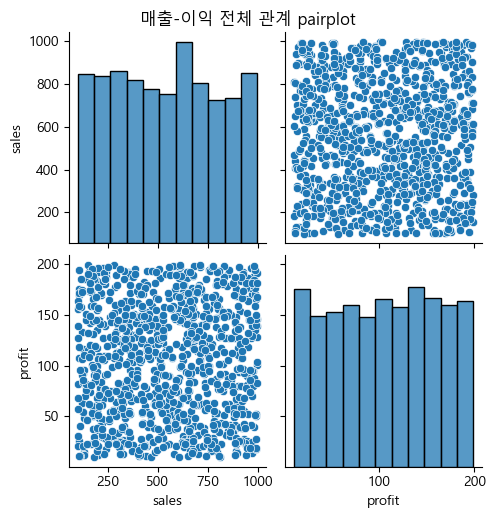

In [47]:
# 수치형 변수 간 전체 관계 탐색 --> 여러 변수의 조합 관계를 한번에 확인

sns.pairplot(df[['sales', 'profit']], kind='scatter')

plt.suptitle('매출-이익 전체 관계 pairplot', y=1.02)
plt.show()

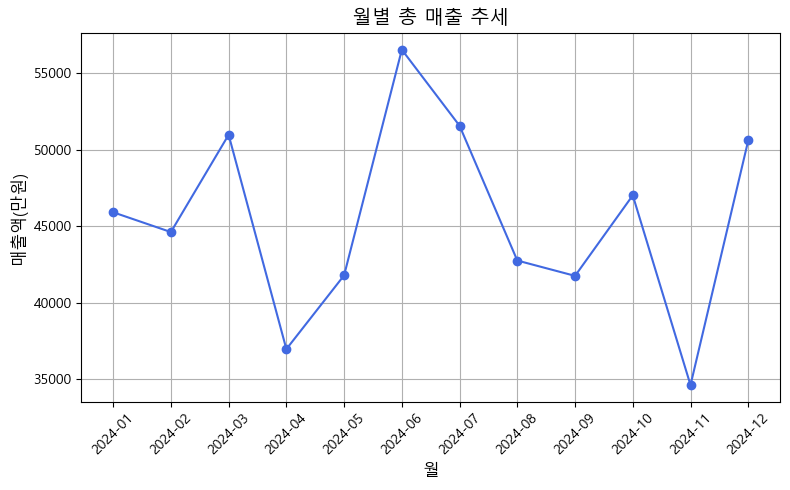

In [51]:
# Matplotlib

# 월별 총 매출 추세(시간 순서)

# 월 단위 매출 집계
df = pd.read_csv('./data/random_ex_data.csv')
df['date'] = pd.to_datetime(df['date'])
df
df_month = df.groupby(df['date'].dt.to_period('M')).sum(numeric_only=True)
df_month.index = df_month.index.astype(str)

plt.figure(figsize=(8,5))
plt.plot(df_month.index, df_month['sales'], marker='o', color='royalblue')

plt.title('월별 총 매출 추세', fontsize=14)
plt.xlabel('월', fontsize=12)
plt.ylabel('매출액(만원)', fontsize=12)
plt.grid(True)

# x 축 눈금 라벨 회전
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


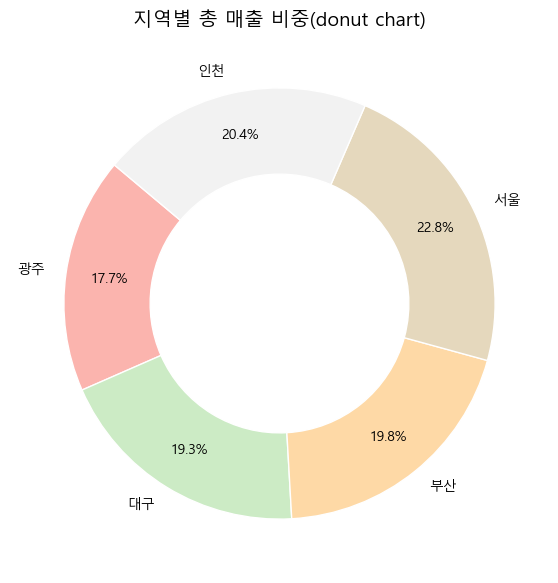

In [58]:
# 자역별 평균 매출 비교 (donut chart)

region_sales = df.groupby('region')['sales'].sum()
colors = plt.cm.Pastel1(np.linspace(0,1, len(region_sales)))

fig, ax = plt.subplots(figsize=(7,7))
wedges, texts, autotexts = ax.pie(
  region_sales,
  labels=region_sales.index,
  autopct='%1.1f%%',
  startangle=140,
  colors=colors,
  pctdistance=0.8,
  wedgeprops=dict(width=0.4, edgecolor='w')
)

ax.set_title('지역별 총 매출 비중(donut chart)', fontsize=14, fontweight='bold')
plt.show()

In [60]:
# 월별 + 지역별 총 매출 현황
df['month'] = df['date'].dt.strftime('%Y-%m')
df_month_region = df.groupby(['month', 'region'])['sales'].sum().reset_index()
df_month_region

# plotly 그래프
fig = px.line(
  df_month_region,
  x='month',
  y='sales',
  color='region',
  title='지역별 월간 매출 추세',
  markers=True
)

fig.update_layout(
  xaxis_title='월',
  yaxis_title='매출액(만원)',
  legend_title='지역'
)

fig.show()

In [64]:
# 지역별 평균 매출 지도 시각화(Folium)

# 지역별 평균 매출
region_sales = df.groupby('region')['sales'].mean()

# 지역별 위도/경도 좌표 정리
region_coords = {
  '서울' : [37.5665, 126.9780],
  '부산' : [37.1796, 129.0756],
  '대구' : [35.8714, 128.6014],
  '광주' : [35.1595, 126.8526],
  '인천' : [37.4563, 126.7052]
}

# 지도 생성
m = folium.Map(location=[36.5, 127.8], zoom_start=7)

# 각 지역에 CircleMarker 추가
for region, avg_sales in region_sales.items():
  folium.CircleMarker(
  location=region_coords[region],
  radius=avg_sales / 50, # 매출 크기에 비레한 원 크기
  color='blue',
  fill=True,
  fill_opacity=0.6,
  popup=f"{region}: {avg_sales :.1f}만원"
).add_to(m)

# 자도 저장 및 표시
m.save('sales_map.html')
m
